# Notebook 04 — Per-Device Event-Conditioned Reliability Analysis

**Motivation.** Notebooks 02–03 analysed all six end devices pooled together for every event comparison (E1–E7). The supervisor asked for the analysis to be repeated **per device**, rather than only as a deployment-wide sum, so that pooled findings can be checked for whether they hold uniformly across devices or are driven by a subset of them.

**What this notebook does NOT do.** It does not redefine or recompute any event thresholds. See the note in Section 1 for why.

**What this notebook adds.** For every event, PDR$_{\text{link}}$, sample size, and (where applicable) the Mann–Whitney/rank-biserial comparison are recomputed **within each device separately**, then compared against the pooled result from Notebook 03. A single consistency table and figure at the end summarise whether each pooled effect direction replicates across all six devices.

## 0 · Imports & Load

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
# Configuration note: see main analysis notebooks for alternatives
DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# filtered dataset -- outage intervals excluded only (same convention as Notebook 03)
df_link = df[~df['is_outage']].copy().reset_index(drop=True)

print(f'Full dataset : {len(df):,} rows')
print(f'df_link      : {len(df_link):,} rows')
print(f'Devices      : {sorted(df_link["device_id"].unique())}')
print(f'Campaign     : {df["time"].min().date()} \u2192 {df["time"].max().date()}')

Full dataset : 2,634,930 rows
df_link      : 2,634,454 rows
Devices      : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign     : 2024-10-01 → 2025-09-30


In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12, 'axes.titlesize': 13,
    'axes.labelsize': 13, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
C = {'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
     'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488', 'grey': '#BBBBBB',
     'brown': '#882255', 'teal': '#44AA99', 'yellow': '#DDCC77'}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
FIG_DIR = Path('../figures/4')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    # fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/4/{name}')
    plt.show()


def pdr_grp(grp):
    rx = len(grp)
    lost = int(grp['tx_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


print('Style ready.')

Style ready.


## 1 · Do the Event Thresholds Need to Be Recomputed Per Device?

**No.** Every event threshold is grounded in something external to this specific deployment: a WHO exposure guideline (E3), a sensor-noise repeatability bound (E2), an ASHRAE comfort band (E5), a fixed signal-quality scale (E7), a calendar definition (E2), or a deployment-wide distributional split reported as such in the methodology (E1, E4). Recomputing any of these per device would silently change what the event *means*: "high CO\u2082" would stop being a comparable occupancy state across rooms and instead become "high relative to this room's own typical range", which conflates the event with the room's baseline ventilation and occupancy profile, and breaks comparability with the absolute health/regulatory thresholds cited in the methodology.

**What changes in this notebook is therefore not the event definitions, but how the outcome is reported.** For every event, PDR$_{\text{link}}$ (and, where the group sizes allow it, the comparison test) is recomputed separately **within each device**, using the exact same category boundaries as Notebook 03. This directly tests whether a pooled effect (e.g. "CO\u2082-rising intervals collapse PDR sharply") is a building-wide phenomenon or concentrated in specific rooms — which matters directly for the collision-dominated / shared-mechanism interpretation argued in Chapter 7.

In [3]:
# Device reference table -- distance comes directly from the data;
# room labels are the same descriptive labels used for figures in Notebook 02
# (not a column in the dataset, included here only for readability).
ROOM_LABELS = {
    'ED0': 'Hardware', 'ED1': 'Lab', 'ED2': 'Office',
    'ED3': 'Office', 'ED4': 'Server Room', 'ED5': 'Kitchen',
}

device_ref = (
    df.groupby('device_id')['distance'].first()
    .reset_index()
    .rename(columns={'distance': 'distance_m'})
)
device_ref['room'] = device_ref['device_id'].map(ROOM_LABELS)
device_ref = device_ref.sort_values('device_id').reset_index(drop=True)
print(device_ref.to_string(index=False))

device_id  distance_m        room
      ED0          10    Hardware
      ED1           8         Lab
      ED2          23      Office
      ED3          18      Office
      ED4          37 Server Room
      ED5          40     Kitchen


## 2 · Per-Device Analysis Framework

In [4]:
def per_device_pdr_table(event_col, categories=None):
    """
    PDR_link and n for every (device, event-category) combination.
    Returns (long_df, wide_pdr, wide_n); wide_* are device x category pivots.
    """
    devices = sorted(df_link['device_id'].unique())
    if categories is None:
        categories = sorted(df_link[event_col].dropna().unique())

    rows = []
    for dev in devices:
        g_dev = df_link[df_link['device_id'] == dev]
        for cat in categories:
            g = g_dev[g_dev[event_col] == cat]
            n = len(g)
            pdr = pdr_grp(g) if n > 0 else np.nan
            rows.append({'device_id': dev, 'category': cat, 'n': n, 'pdr': pdr})

    long_df = pd.DataFrame(rows)
    wide_pdr = long_df.pivot(index='device_id', columns='category', values='pdr')[categories]
    wide_n = long_df.pivot(index='device_id', columns='category', values='n')[categories]
    return long_df, wide_pdr, wide_n


def per_device_binary_compare(event_col, group1, group0=None, min_n=5):
    """
    Per-device Mann-Whitney PDR comparison, mirroring Notebook 03's pdr_compare
    but computed separately within each device. Devices with fewer than min_n
    rows in either group are flagged rather than tested.
    """
    devices = sorted(df_link['device_id'].unique())
    rows = []
    for dev in devices:
        g_dev = df_link[df_link['device_id'] == dev]
        g1 = g_dev[g_dev[event_col] == group1]
        g0 = g_dev[g_dev[event_col] != group1] if group0 is None else g_dev[g_dev[event_col] == group0]
        n1, n0 = len(g1), len(g0)

        if n1 < min_n or n0 < min_n:
            rows.append({'device_id': dev, 'n1': n1, 'n0': n0,
                         'pdr1': pdr_grp(g1) if n1 > 0 else np.nan,
                         'pdr0': pdr_grp(g0) if n0 > 0 else np.nan,
                         'diff_pp': np.nan, 'p_value': np.nan,
                         'effect_r': np.nan, 'significant': False,
                         'note': 'insufficient n'})
            continue

        pdr1, pdr0 = pdr_grp(g1), pdr_grp(g0)
        stat, p = stats.mannwhitneyu(g1['t_radio'].values, g0['t_radio'].values,
                                      alternative='two-sided')
        r = 1 - 2 * stat / (n1 * n0)
        rows.append({'device_id': dev, 'n1': n1, 'n0': n0,
                     'pdr1': pdr1, 'pdr0': pdr0,
                     'diff_pp': pdr1 - pdr0, 'p_value': p,
                     'effect_r': r, 'significant': p < 0.05, 'note': ''})
    return pd.DataFrame(rows)


def plot_device_grouped_bar(wide_pdr, title, ylabel='PDR_link (%)', colors=None,
                             fname=None, figsize=(11, 5)):
    """Grouped bar chart: one group of bars per device, one bar per category."""
    devices = wide_pdr.index.tolist()
    categories = wide_pdr.columns.tolist()
    n_cat = len(categories)
    if colors is None:
        palette = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
        colors = palette[:n_cat]

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(devices)) * 0.85
    total_width = 0.7
    w = total_width / n_cat

    for j, cat in enumerate(categories):
        offset = (j - (n_cat - 1) / 2) * w
        vals = wide_pdr[cat].values
        bars = ax.bar(x + offset, vals, w, color=colors[j % len(colors)],
                      alpha=0.88, edgecolor='white', label=str(cat))
        for xi, v in zip(x + offset, vals):
            if not np.isnan(v):
                ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(devices, fontsize=13, fontweight='bold')
    ax.margins(x=0.04)
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, ncol=min(n_cat, 4))

    fig.tight_layout()
    if fname:
        save_fig(fig, fname)
    return fig, ax


def plot_device_heatmap(wide_pdr, title, fname=None, figsize=(9, 4.5), cmap='RdYlGn'):
    """Device x category heatmap -- used for E9 (6 SF categories x 6 devices)."""
    fig, ax = plt.subplots(figsize=figsize)
    data = wide_pdr.values.astype(float)
    vmin = np.nanmin(data) - 2
    vmax = np.nanmax(data) + 2
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(wide_pdr.columns)))
    ax.set_xticklabels(wide_pdr.columns, fontsize=12, fontweight='bold')
    ax.set_yticks(range(len(wide_pdr.index)))
    ax.set_yticklabels(wide_pdr.index, fontsize=12, fontweight='bold')

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='black')

    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label('PDR_link (%)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    fig.tight_layout()
    if fname:
        save_fig(fig, fname)
    return fig, ax


print('Per-device framework ready.')

Per-device framework ready.


## 3 · CO₂ Tier per Device (E1)

In [5]:
print('=' * 60)
print('E1: CO2 Tier PDR, per device')
print('=' * 60)
long_e1, wide_e1_pdr, wide_e1_n = per_device_pdr_table(
    'e1_co2_tier', ['background', 'moderate', 'high'])
print(wide_e1_pdr.round(2))
print('\nn per cell:')
print(wide_e1_n)

E1: CO2 Tier PDR, per device
category   background  moderate   high
device_id                             
ED0             98.36     97.78  95.90
ED1             97.92     96.98  94.37
ED2             98.32     98.35  96.32
ED3             97.34     97.45  94.96
ED4             98.18     97.14  90.82
ED5             99.53     97.89  94.24

n per cell:
category   background  moderate   high
device_id                             
ED0            252792    133997  53297
ED1            271486    127682  35302
ED2            264065    132170  44605
ED3            260030    120703  52766
ED4            289433    135244  10659
ED5            332845     92745  24633


  Saved: figures/4/04_a1_co2_tier_pdr_per_device


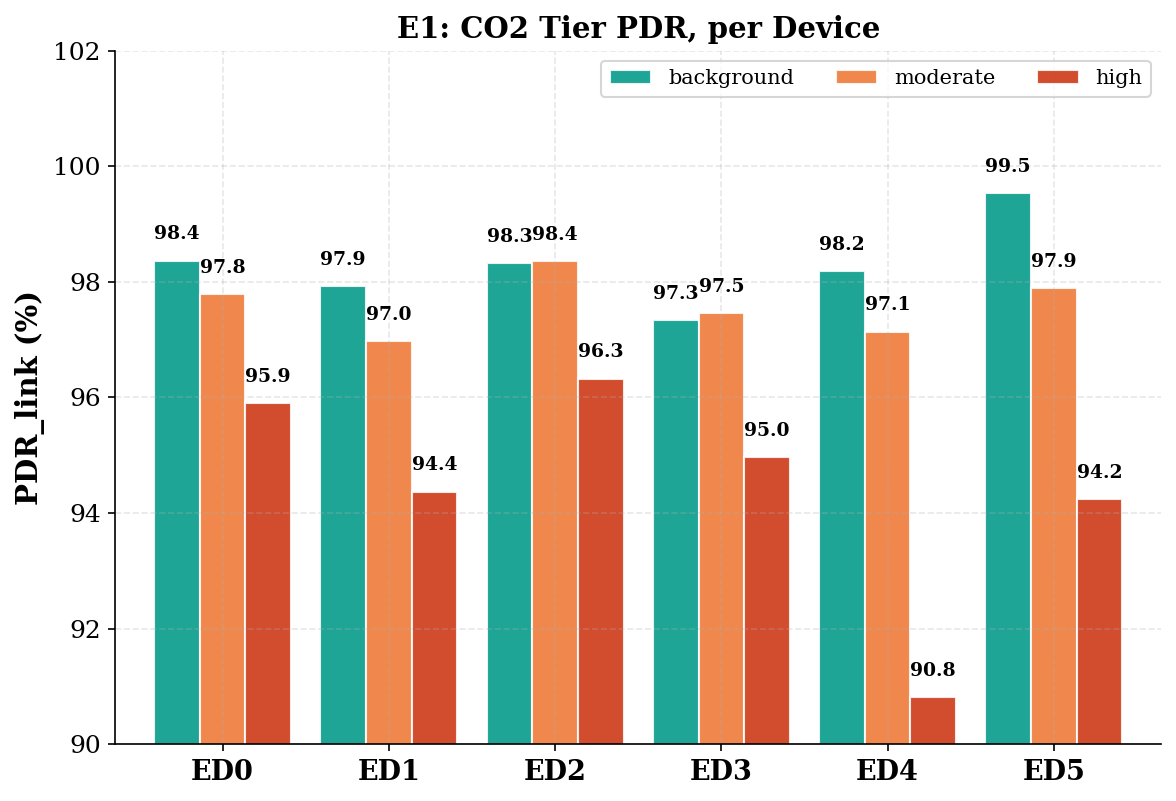

In [6]:
# Fig 04-A1 -- E1 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices = wide_e1_pdr.index.tolist()
cats1 = wide_e1_pdr.columns.tolist()
x0 = np.arange(len(devices)) * 0.85
w0 = 0.7 / len(cats1)
colors1 = [C['green'], C['orange'], C['red']]
for j, cat in enumerate(cats1):
    offset = (j - (len(cats1) - 1) / 2) * w0
    vals = wide_e1_pdr[cat].values
    ax.bar(x0 + offset, vals, w0, color=colors1[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x0 + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
ax.set_xticks(x0)
ax.set_xticklabels(devices, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=3)
ax.set_title('E1: CO2 Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_a1_co2_tier_pdr_per_device')

## 4 · Office Hours per Device (E2)

In [7]:
print('=' * 60)
print('E2: Office Hours vs Off-Peak PDR, per device')
print('=' * 60)
e2_dev = per_device_binary_compare('e2_office_hours', 1, 0)
print(e2_dev.to_string(index=False))

E2: Office Hours vs Off-Peak PDR, per device
device_id     n1     n0      pdr1      pdr0   diff_pp       p_value  effect_r  significant note
      ED0 128127 311959 96.967472 98.263159 -1.295687 6.412534e-123 -0.010145         True     
      ED1 127115 307355 96.643351 97.638728 -0.995377  3.129531e-48 -0.007045         True     
      ED2 129013 311827 97.524341 98.374656 -0.850315  7.450857e-53 -0.006183         True     
      ED3 126079 307420 96.079223 97.489044 -1.409820 4.190172e-100 -0.010071         True     
      ED4 127692 307644 97.500115 97.729915 -0.229801  5.265110e-05 -0.001804         True     
      ED5 130492 319731 97.472288 99.471425 -1.999137  0.000000e+00 -0.010535         True     


  Saved: figures/4/04_b_office_hours_pdr_per_device


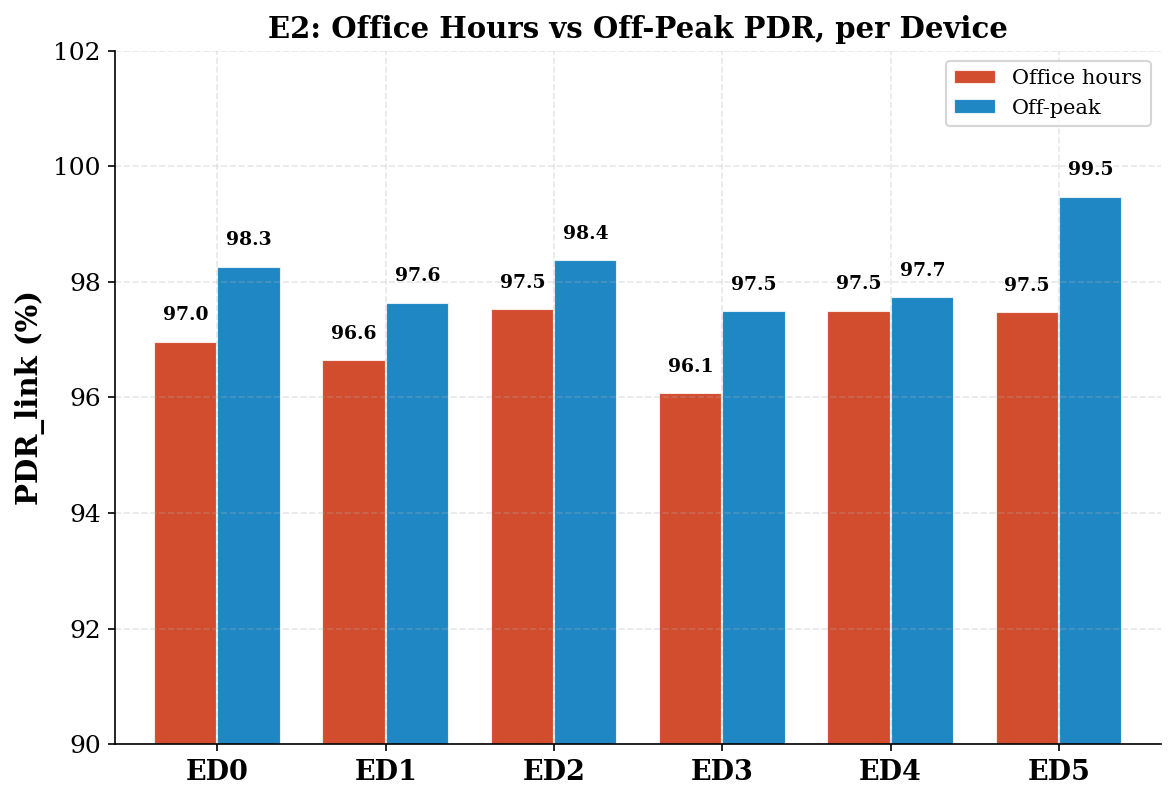

In [8]:
# Fig 04-B -- E2 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices = e2_dev['device_id'].tolist()
x0 = np.arange(len(devices)) * 0.85
w0 = 0.32
b1 = ax.bar(x0 - w0 / 2, e2_dev['pdr1'], w0, color=C['red'], alpha=0.88,
            edgecolor='white', label='Office hours')
b2 = ax.bar(x0 + w0 / 2, e2_dev['pdr0'], w0, color=C['blue'], alpha=0.88,
            edgecolor='white', label='Off-peak')
for bar, v in zip(b1, e2_dev['pdr1']):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(b2, e2_dev['pdr0']):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x0)
ax.set_xticklabels(devices, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10)
ax.set_title('E2: Office Hours vs Off-Peak PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_b_office_hours_pdr_per_device')

## 5 · PM2.5 Tier per Device (E3)

In [9]:
print('=' * 60)
print('E3: PM2.5 Absolute Tier PDR, per device')
print('=' * 60)
long_e3, wide_e3_pdr, wide_e3_n = per_device_pdr_table(
    'e3_pm25_tier', ['clean', 'moderate', 'elevated'])
print('PDR_link (%):')
print(wide_e3_pdr.round(2))
print('\nn per cell (note how sparse "elevated" is outside ED5):')
print(wide_e3_n)

E3: PM2.5 Absolute Tier PDR, per device
PDR_link (%):
category   clean  moderate  elevated
device_id                           
ED0        98.27     95.15     74.38
ED1        97.71     94.10     81.16
ED2        98.47     94.87     67.65
ED3        97.38     94.79     76.37
ED4        97.67     78.83       NaN
ED5        99.16     98.09     83.35

n per cell (note how sparse "elevated" is outside ED5):
category    clean  moderate  elevated
device_id                            
ED0        402989     35294      1803
ED1        395687     38042       741
ED2        406212     34034       594
ED3        392105     40376      1018
ED4        435228       108         0
ED5        380131     67298      2794


  Saved: figures/4/04_c_pm25_tier_pdr_per_device


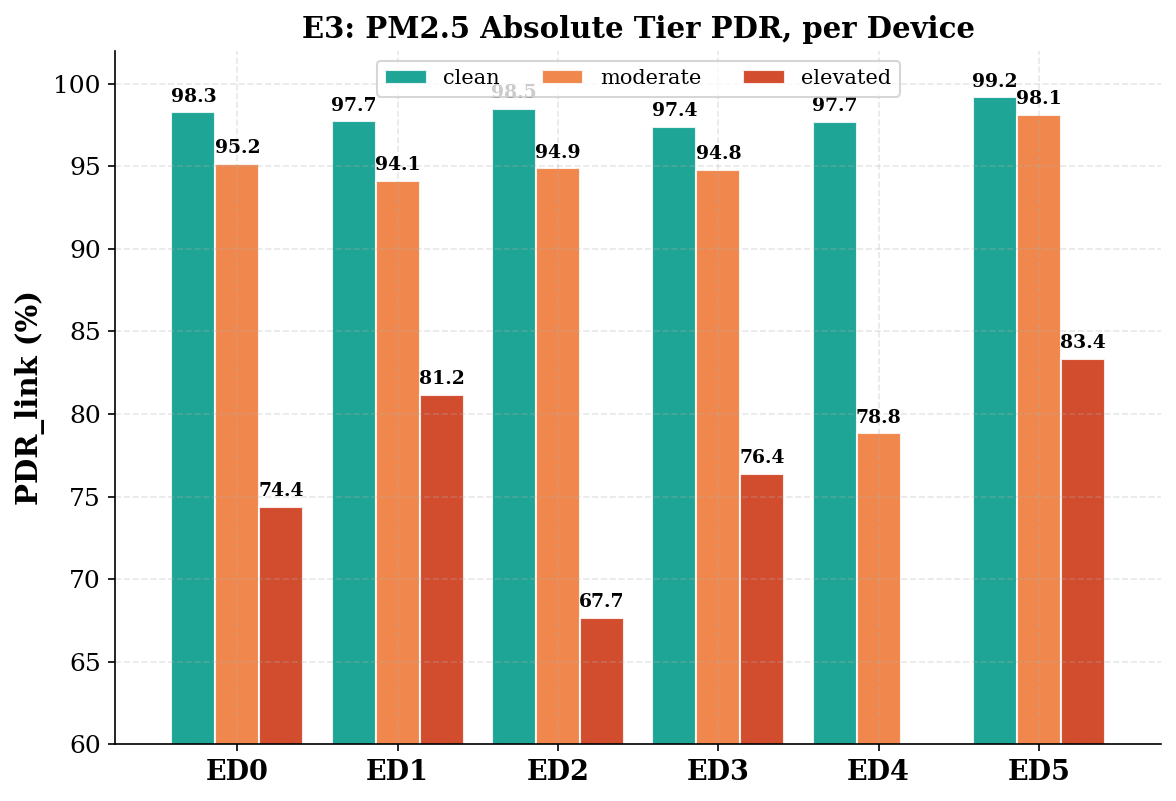

In [10]:
# Fig 04-C -- E3 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices3 = wide_e3_pdr.index.tolist()
cats4 = wide_e3_pdr.columns.tolist()
x0 = np.arange(len(devices3)) * 0.85
w0 = 0.7 / len(cats4)
colors4 = [C['green'], C['orange'], C['red']]
for j, cat in enumerate(cats4):
    offset = (j - (len(cats4) - 1) / 2) * w0
    vals = wide_e3_pdr[cat].values
    ax.bar(x0 + offset, vals, w0, color=colors4[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x0 + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.4, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
ax.set_xticks(x0)
ax.set_xticklabels(devices3, fontsize=13, fontweight='bold')
ax.margins(x=0.06)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=3)
ax.set_title('E3: PM2.5 Absolute Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(60, 102)

fig.tight_layout()
save_fig(fig, '04_c_pm25_tier_pdr_per_device')

## 6 · Temperature Tier per Device (E4)

In [11]:
print('=' * 60)
print('E4: Temperature Tier PDR, per device')
print('=' * 60)
long_e4, wide_e4_pdr, wide_e4_n = per_device_pdr_table(
    'e4_temp_tier', ['cool', 'moderate', 'warm'])
print(wide_e4_pdr.round(2))

E4: Temperature Tier PDR, per device
category    cool  moderate   warm
device_id                        
ED0        97.76     97.84  98.08
ED1        96.66     96.99  98.28
ED2        97.18     98.02  98.68
ED3        97.18     97.60  96.45
ED4        96.32     98.12  98.63
ED5        98.40     99.26  99.17


  Saved: figures/4/04_d1_temperature_tier_pdr_per_device


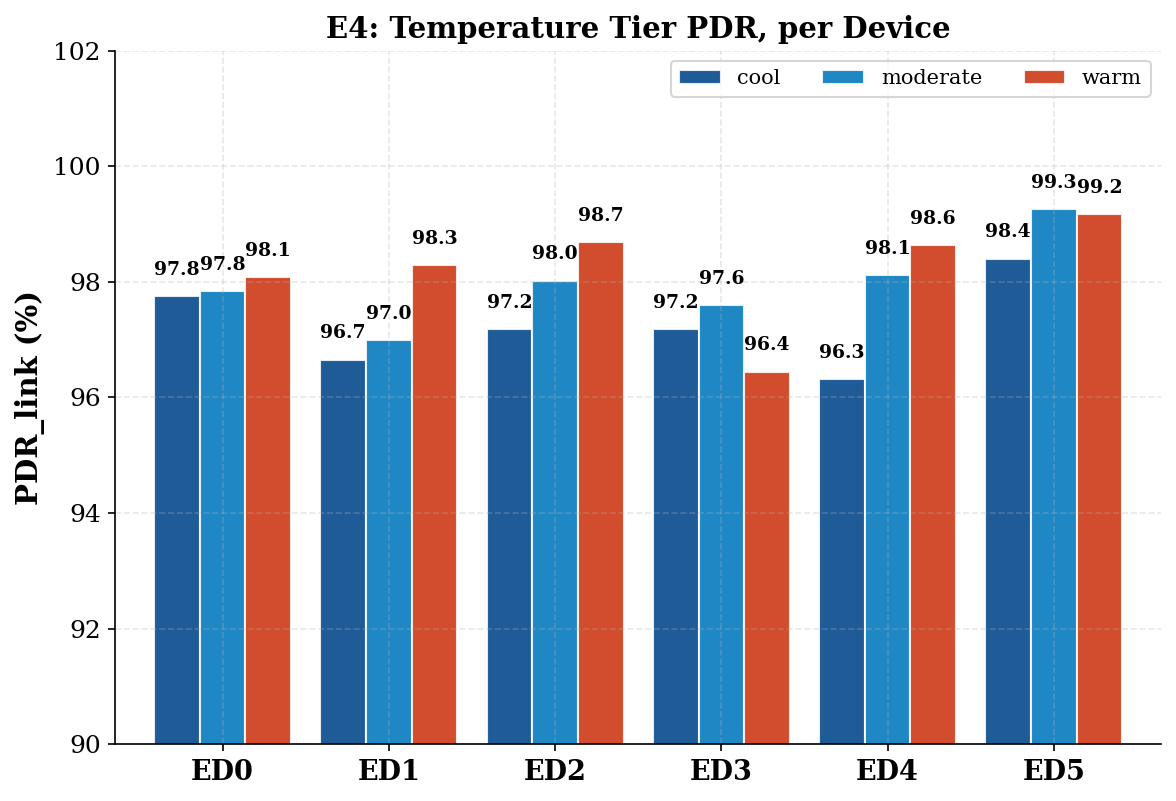

In [12]:
# Fig 04-D1 -- E4 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices4 = wide_e4_pdr.index.tolist()
cats5 = wide_e4_pdr.columns.tolist()
x0 = np.arange(len(devices4)) * 0.85
w0 = 0.7 / len(cats5)
colors5 = [C['navy'], C['blue'], C['red']]
for j, cat in enumerate(cats5):
    offset = (j - (len(cats5) - 1) / 2) * w0
    vals = wide_e4_pdr[cat].values
    ax.bar(x0 + offset, vals, w0, color=colors5[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x0 + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
ax.set_xticks(x0)
ax.set_xticklabels(devices4, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=3)
ax.set_title('E4: Temperature Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_d1_temperature_tier_pdr_per_device')

## 7 · Humidity Tier per Device (E5)

In [13]:
print('=' * 60)
print('E5: Humidity Tier PDR, per device')
print('=' * 60)
long_e5, wide_e5_pdr, wide_e5_n = per_device_pdr_table(
    'e5_humidity_tier', ['dry', 'normal', 'humid'])
print(wide_e5_pdr.round(2))
print('\nn per cell (humid tier is expected to be sparse and ED5-concentrated):')
print(wide_e5_n)

E5: Humidity Tier PDR, per device
category     dry  normal   humid
device_id                       
ED0        96.00   98.29     NaN
ED1        96.91   97.44   94.65
ED2        97.50   98.34     NaN
ED3        95.71   97.28  100.00
ED4        98.17   97.60     NaN
ED5        97.37   98.97     NaN

n per cell (humid tier is expected to be sparse and ED5-concentrated):
category      dry  normal  humid
device_id                       
ED0         77216  362870      0
ED1         72325  361420    725
ED2        110686  330154      0
ED3         55890  377601      8
ED4         47043  388293      0
ED5         24482  425741      0


  Saved: figures/4/04_d2_humidity_tier_pdr_per_device


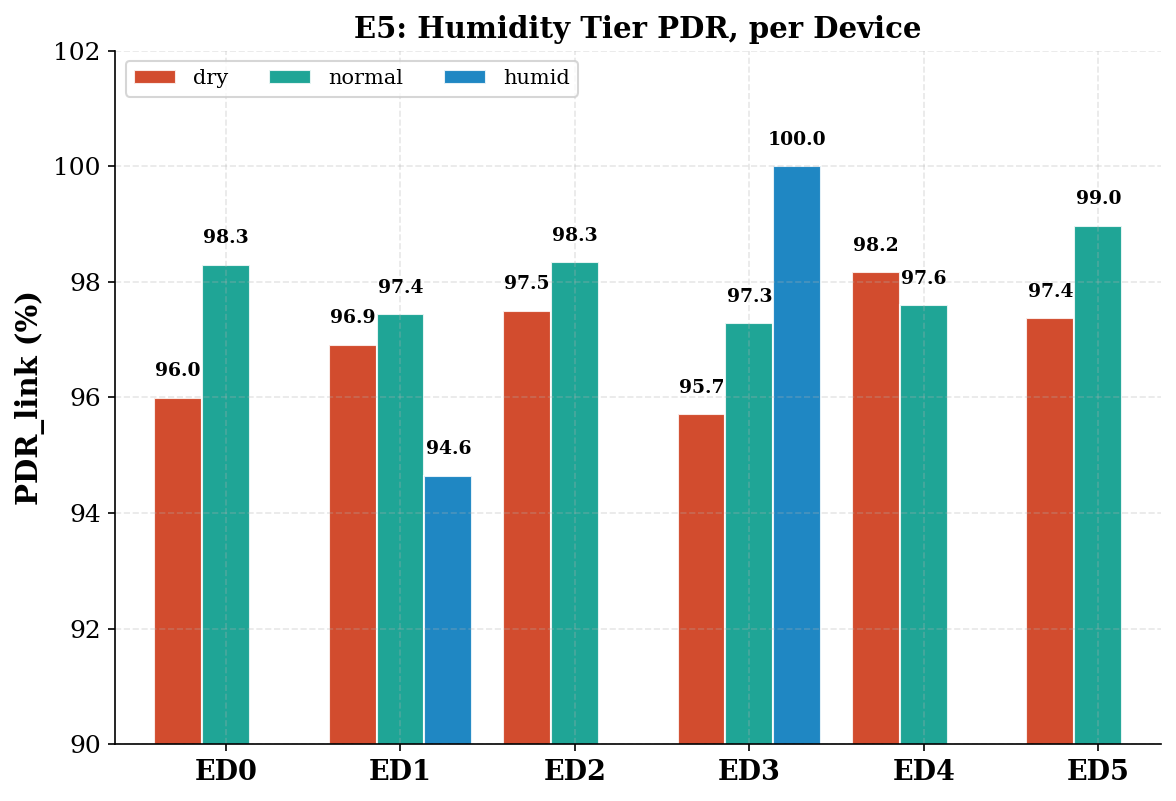

In [14]:
# Fig 04-D2 -- E5 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices5 = wide_e5_pdr.index.tolist()
cats6 = wide_e5_pdr.columns.tolist()
x1 = np.arange(len(devices5)) * 0.85
w1 = 0.7 / len(cats6)
colors6 = [C['red'], C['green'], C['blue']]
for j, cat in enumerate(cats6):
    offset = (j - (len(cats6) - 1) / 2) * w1
    vals = wide_e5_pdr[cat].values
    ax.bar(x1 + offset, vals, w1, color=colors6[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x1 + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
ax.set_xticks(x1)
ax.set_xticklabels(devices5, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=3)
ax.set_title('E5: Humidity Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_d2_humidity_tier_pdr_per_device')

## 8 · Spreading Factor per Device (E6)

In [15]:
print('=' * 60)
print('E6: PDR by Spreading Factor, per device')
print('=' * 60)
long_e6, wide_e6_pdr, wide_e6_n = per_device_pdr_table(
    'e6_sf', [7, 8, 9, 10, 11, 12])
wide_e6_pdr.columns = [f'SF{c}' for c in wide_e6_pdr.columns]
wide_e6_n.columns = [f'SF{c}' for c in wide_e6_n.columns]
print(wide_e6_pdr.round(2))
print('\nn per cell (recall SF11/SF12 were dropped from rotation on 4 Jul 2025):')
print(wide_e6_n)

E6: PDR by Spreading Factor, per device
             SF7    SF8    SF9   SF10   SF11   SF12
device_id                                          
ED0        98.78  98.55  97.76  97.84  96.24  96.80
ED1        98.46  98.20  97.38  96.92  95.77  95.77
ED2        99.27  98.96  98.13  97.94  96.04  96.69
ED3        97.57  97.68  96.76  97.14  96.07  96.42
ED4        98.65  98.34  97.51  97.18  96.05  97.15
ED5        99.16  98.98  98.97  99.00  98.03  98.63

n per cell (recall SF11/SF12 were dropped from rotation on 4 Jul 2025):
             SF7    SF8    SF9   SF10   SF11   SF12
device_id                                          
ED0        89584  89246  86828  83700  44947  45781
ED1        89429  88719  85496  82085  43599  45142
ED2        90109  89606  87103  83905  44808  45309
ED3        88623  87961  84867  81860  44504  45684
ED4        89538  89055  85892  81424  43914  45513
ED5        89652  89878  88460  87778  47382  47073


  Saved: figures/4/04_e_sf_pdr_per_device


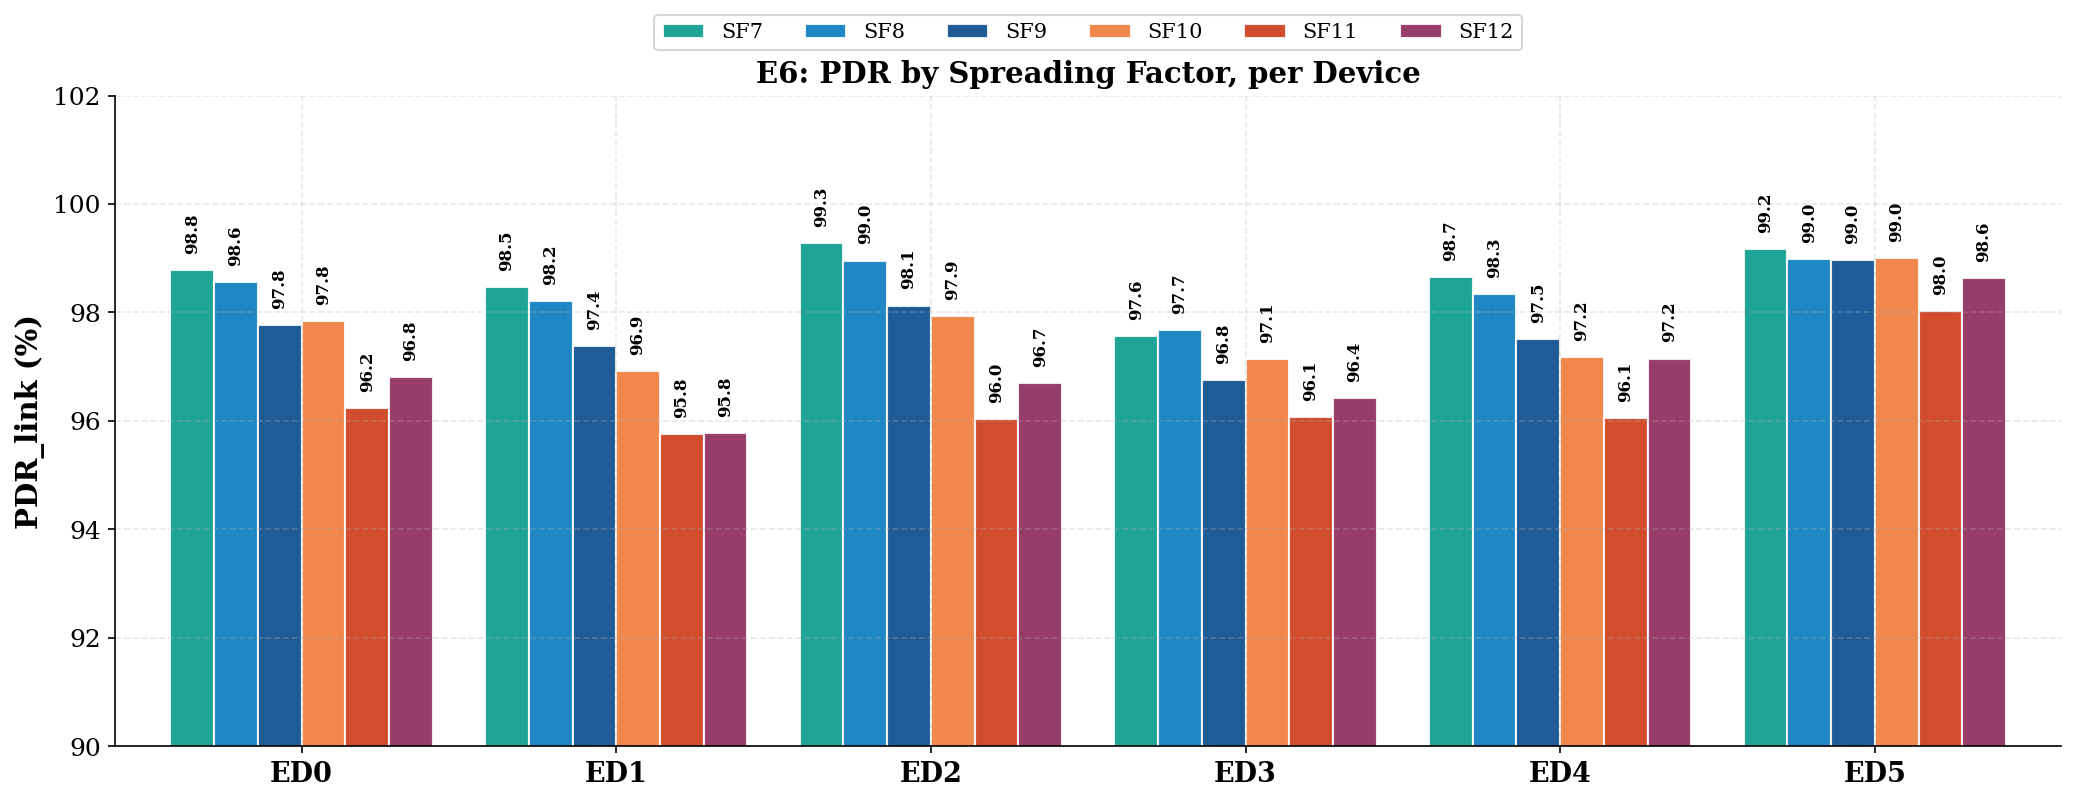

In [16]:
# Fig 04-E -- E6 per-device breakdown
devices6 = wide_e6_pdr.index.tolist()
cats7 = wide_e6_pdr.columns.tolist()
x = np.arange(len(devices6)) * 0.9
w = 0.75 / len(cats7)
colors7 = [C['green'], C['blue'], C['navy'], C['orange'], C['red'], C['brown']]

fig, ax = plt.subplots(figsize=(14, 5.5))
for j, cat in enumerate(cats7):
    offset = (j - (len(cats7) - 1) / 2) * w
    vals = wide_e6_pdr[cat].values
    ax.bar(x + offset, vals, w, color=colors7[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold', rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(devices6, fontsize=13, fontweight='bold')
ax.margins(x=0.03)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=6, loc='upper center', bbox_to_anchor=(0.5, 1.14))
ax.set_title('E6: PDR by Spreading Factor, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_e_sf_pdr_per_device')

## 9 · ESP Tier per Device (E7)

In [17]:
print('=' * 60)
print('E7: ESP Tier PDR, per device')
print('=' * 60)
long_e7, wide_e7_pdr, wide_e7_n = per_device_pdr_table(
    'e7_esp_tier', ['poor', 'moderate', 'strong'])
print(wide_e7_pdr.round(2))
print('\nn per cell:')
print(wide_e7_n)

E7: ESP Tier PDR, per device
category    poor  moderate  strong
device_id                         
ED0        97.11     97.05   97.99
ED1        95.98     95.99   97.55
ED2        95.91     97.60   98.24
ED3        97.00     96.67   97.12
ED4        97.32     96.59   97.75
ED5        54.93     97.77   99.21

n per cell:
category    poor  moderate  strong
device_id                         
ED0        19700     31069  389317
ED1        21142     35486  377842
ED2        16581     19777  404482
ED3        28049     36198  369252
ED4        12912     26630  395794
ED5           39     98688  351496


  Saved: figures/4/04_f_esp_tier_pdr_per_device


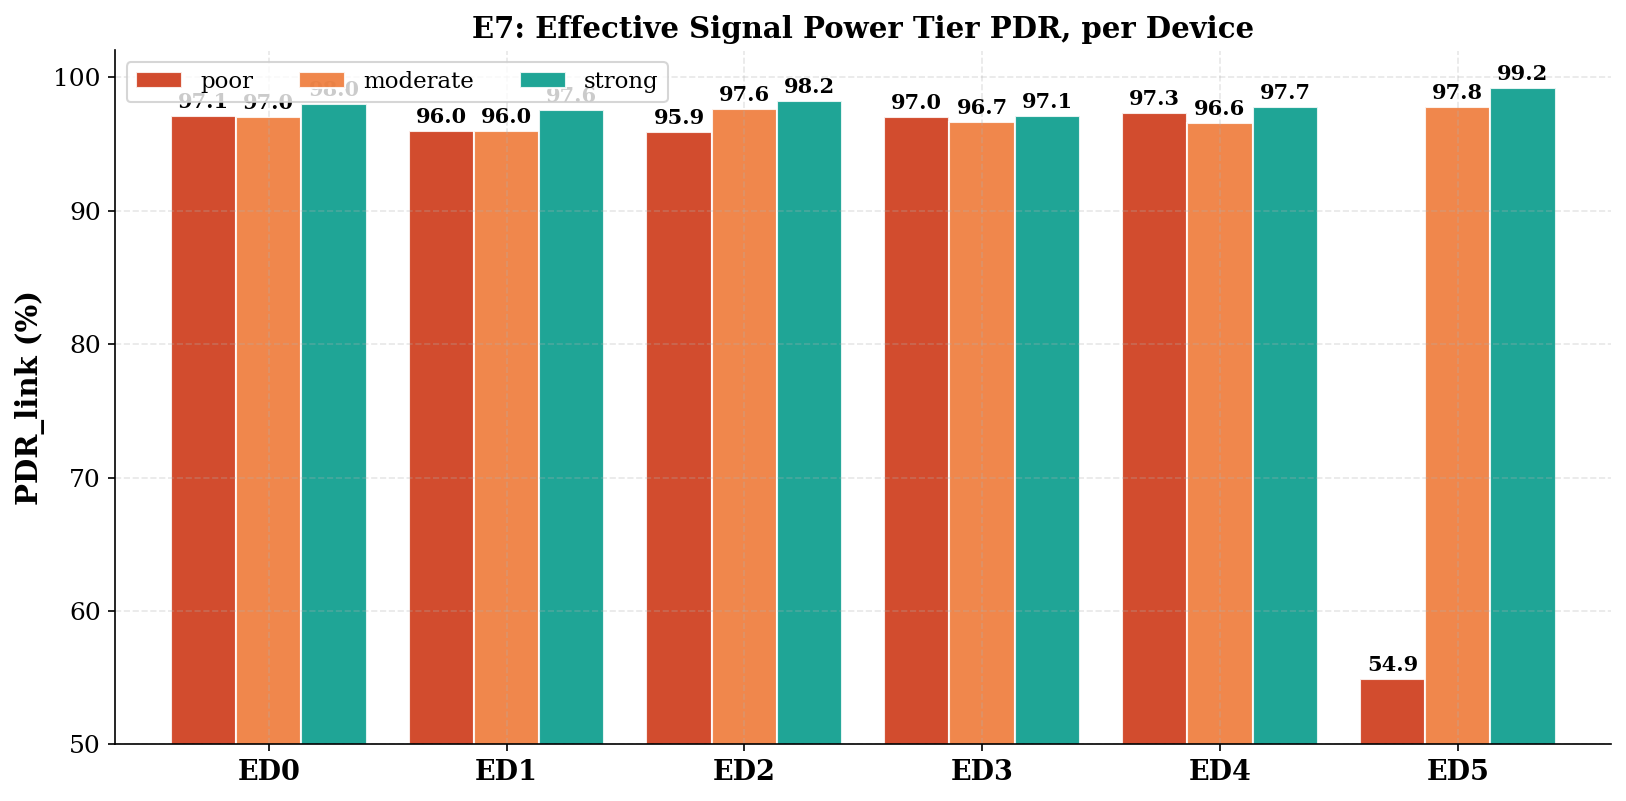

In [18]:
# Fig 04-F -- E7 per-device breakdown
devices7 = wide_e7_pdr.index.tolist()
cats8 = wide_e7_pdr.columns.tolist()
x = np.arange(len(devices7)) * 0.85
w = 0.7 / len(cats8)
colors8 = [C['red'], C['orange'], C['green']]

fig, ax = plt.subplots(figsize=(11, 5.5))
for j, cat in enumerate(cats8):
    offset = (j - (len(cats8) - 1) / 2) * w
    vals = wide_e7_pdr[cat].values
    ax.bar(x + offset, vals, w, color=colors8[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(devices7, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=11, ncol=3)
ax.set_title('E7: Effective Signal Power Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(50, 102)

fig.tight_layout()
save_fig(fig, '04_f_esp_tier_pdr_per_device')

## 10 · Consistency Summary — Does the Pooled Effect Replicate in Every Device?

For each event's primary contrast (the same pairs reported in Notebook 03's summary table), this section compares the pooled PDR difference against the direction of the PDR difference computed independently within each device. "Consistent" means all six devices agree in direction with each other (not necessarily with the pooled result, though in practice a 6/6 agreement will match the pooled sign too, since the pooled figure is a weighted average of the six).

In [19]:
print('=' * 60)
print('CONSISTENCY SUMMARY -- pooled direction vs per-device direction')
print('=' * 60)

primary_contrasts = [
    ('E1', 'e1_co2_tier', 'high', 'background', 'High CO2 vs Background'),
    ('E2', 'e2_office_hours', 1, 0, 'Office hours vs off-peak'),
    ('E3', 'e3_pm25_tier', 'elevated', 'clean', 'Elevated vs Clean PM2.5'),
    ('E4', 'e4_temp_tier', 'warm', 'cool', 'Warm vs Cool'),
    ('E5', 'e5_humidity_tier', 'humid', 'dry', 'Humid vs Dry'),
    ('E6', 'e6_sf', 12, 7, 'SF12 vs SF7'),
    ('E7', 'e7_esp_tier', 'poor', 'strong', 'Poor vs Strong ESP'),
]

def pooled_pdr_compare(event_col, group1, group0=None):
    g1 = df_link[df_link[event_col] == group1]
    g0 = df_link[df_link[event_col] != group1] if group0 is None else df_link[df_link[event_col] == group0]
    return pdr_grp(g1) - pdr_grp(g0)

consistency_rows = []
per_device_detail = {}

for eid, col, g1, g0, label in primary_contrasts:
    dev_table = per_device_binary_compare(col, g1, g0, min_n=5)
    per_device_detail[eid] = dev_table

    valid = dev_table.dropna(subset=['diff_pp'])
    n_worse = int((valid['diff_pp'] < 0).sum())
    n_better = int((valid['diff_pp'] > 0).sum())
    n_valid = len(valid)

    pooled_diff = pooled_pdr_compare(col, g1, g0)
    pooled_dir = 'worse' if pooled_diff < 0 else 'better'
    consistent = (n_worse == n_valid) or (n_better == n_valid)

    consistency_rows.append({
        'Event': eid, 'Comparison': label,
        'Pooled_diff_pp': pooled_diff, 'Pooled_direction': pooled_dir,
        'Devices_worse': n_worse, 'Devices_better': n_better,
        'Devices_valid': n_valid, 'Consistent_across_devices': consistent,
    })

    print(f"\n{eid}: {label}")
    print(f"  Pooled            : {pooled_diff:+.2f} pp ({pooled_dir})")
    print(f"  Devices worse     : {n_worse}/{n_valid}")
    print(f"  Devices better    : {n_better}/{n_valid}")
    print(f"  {'-> CONSISTENT across devices' if consistent else '-> INCONSISTENT (device-dependent)'}")

consistency_df = pd.DataFrame(consistency_rows)
print('\n' + '=' * 60)
print(consistency_df.to_string(index=False))

CONSISTENCY SUMMARY -- pooled direction vs per-device direction

E1: High CO2 vs Background
  Pooled            : -3.25 pp (worse)
  Devices worse     : 6/6
  Devices better    : 0/6
  -> CONSISTENT across devices

E2: Office hours vs off-peak
  Pooled            : -1.13 pp (worse)
  Devices worse     : 6/6
  Devices better    : 0/6
  -> CONSISTENT across devices

E3: Elevated vs Clean PM2.5
  Pooled            : -20.01 pp (worse)
  Devices worse     : 5/5
  Devices better    : 0/5
  -> CONSISTENT across devices

E4: Warm vs Cool
  Pooled            : +0.91 pp (better)
  Devices worse     : 1/6
  Devices better    : 5/6
  -> INCONSISTENT (device-dependent)

E5: Humid vs Dry
  Pooled            : -2.20 pp (worse)
  Devices worse     : 1/2
  Devices better    : 1/2
  -> INCONSISTENT (device-dependent)

E6: SF12 vs SF7
  Pooled            : -1.74 pp (worse)
  Devices worse     : 6/6
  Devices better    : 0/6
  -> CONSISTENT across devices

E7: Poor vs Strong ESP
  Pooled            : -1.3

  Saved: figures/4/04_g_consistency_summary


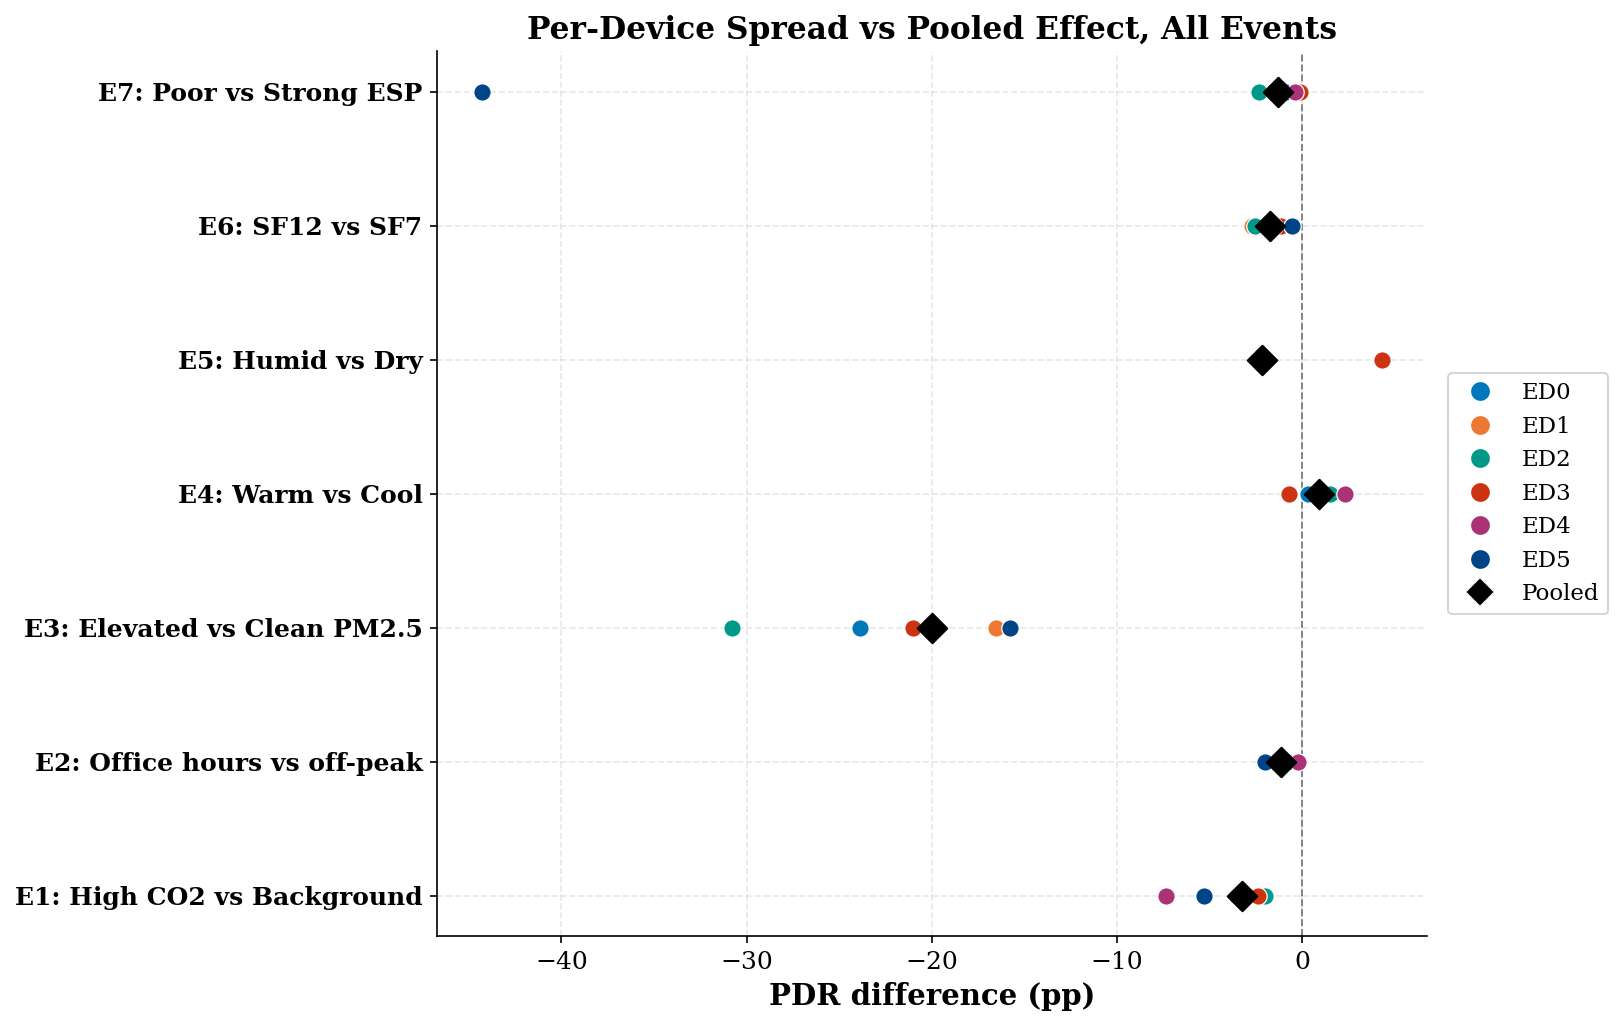

In [20]:
# Fig 04-G -- per-device spread vs pooled effect, all events
fig, ax = plt.subplots(figsize=(11, 7))

event_order = [row['Event'] for row in consistency_rows]
y_positions = {eid: i for i, eid in enumerate(event_order)}
devices_all = sorted(df_link['device_id'].unique())
device_color_map = dict(zip(devices_all, DEVICE_COLORS))

for eid, col, g1, g0, label in primary_contrasts:
    y = y_positions[eid]
    dev_table = per_device_detail[eid]
    for _, row in dev_table.dropna(subset=['diff_pp']).iterrows():
        ax.scatter(row['diff_pp'], y, color=device_color_map[row['device_id']],
                   s=70, zorder=3, edgecolor='white', linewidth=0.6)
    pooled_diff = pooled_pdr_compare(col, g1, g0)
    ax.scatter(pooled_diff, y, color='black', marker='D', s=100, zorder=4)

ax.axvline(x=0, color='grey', lw=0.9, ls='--')
ax.set_yticks(range(len(event_order)))
ax.set_yticklabels([f'{eid}: {label}' for eid, _, _, _, label in primary_contrasts],
                    fontsize=12, fontweight='bold')
ax.set_xlabel('PDR difference (pp)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.set_title('Per-Device Spread vs Pooled Effect, All Events', fontsize=15, fontweight='bold')

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=device_color_map[d],
                       markersize=10, label=d) for d in devices_all]
handles.append(plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
                           markersize=10, label='Pooled'))
ax.legend(handles=handles, fontsize=11, loc='center left', bbox_to_anchor=(1.01, 0.5))

fig.tight_layout()
save_fig(fig, '04_g_consistency_summary')

## 11 · Save Results

In [21]:
# per-device PDR tables for every event, long format, concatenated with an Event column
per_device_long_frames = []
event_tables = {
    'E1': long_e1, 'E3': long_e3, 'E4': long_e3,
    'E5': long_e4, 'E6': long_e5, 'E7': long_e6,
}
for eid, tbl in event_tables.items():
    t = tbl.copy()
    t.insert(0, 'Event', eid)
    per_device_long_frames.append(t)

# binary-comparison events are already tidy per-device tables
for eid, tbl in [('E2', e2_dev)]:
    t = tbl.copy()
    t.insert(0, 'Event', eid)
    per_device_long_frames.append(t)

per_device_results = pd.concat(per_device_long_frames, ignore_index=True, sort=False)
per_device_results.to_csv(DATA_DIR / '4_per_device_results.csv', index=False)

consistency_df.to_csv(DATA_DIR / '4_consistency_summary.csv', index=False)

print(f'Saved: {DATA_DIR / "4_per_device_results.csv"}')
print(f'Saved: {DATA_DIR / "4_consistency_summary.csv"}')
print('\nNotebook 04 complete.')

Saved: ..\data\4_per_device_results.csv
Saved: ..\data\4_consistency_summary.csv

Notebook 04 complete.
